# Modeling Particle in a Box

Reminder to Students: 
You must save your file. It does not automatically save. 

Many parts of this file are already filled in. However, you should still examine what the code is doing as for the next modules (Harmonic oscillator and rigid rotor) you will be required to fill in higher amounts of code

Be sure to answer the questions included along the way in the workbook.

## Import Packages

In [106]:
# A jupyter notebook will often begin with import statements to access certain applications used in the notebook

import numpy as np              #library the expands python support for large and multidimensional arrays.
import sympy as sp              #symbolic math library
import matplotlib.pyplot as plt #plotting and graphing library
import pandas as pd             #pandas data anlysis library
import io                       #Core python input/output library
from scipy.stats import linregress       #Linear regression function from SciPy(contains linear regression function)
from scipy.optimize import curve_fit     #Curve fitting function from SciPy(for least squares regression)
from matplotlib import pyplot as plt
sp.init_printing(use_latex=True) #Use sympy "pretty printing" throughout document where possible.
import seaborn as sns

## Define Constants

Lets start by defining common variables and constants that we can then use through out the entire notebook. Feel free to add more here if you need

In [72]:
#Constants
h = 6.62607015e-34 #J*s
c = 2.99e8 #m/s

# 1-D Particle in a Box

We will start with examining the 1-D particle in a box. 


In [1]:
#Variables

m = 9.109*10**-31 #kg, mass of the particlee we are looking at
a = 1e-9 #length of the box



9.109000000000001e-31


#### Question 1
What is the particle whose mass is given above?

#### Answer 1


## Calculate energy of a single level
Lets start simple. Use the code to calculate the absolute energy of one energy level

In [76]:
#Calculate for one energy level

n= 5

En= ((h**2)*(n**2)) / (8*m*(a**2)) 

print ('The energy level at n=', n, 'is', En)

The energy level at n= 5 is 1.506230295337064e-18


You have now made yourself a simple calculator for the particle in a box. If you want to check your results, you can do a calcuation by hand or double check with this website. 

https://www.vcalc.com/wiki/EmilyB/Energy-of-particle-in-a-box


You are not far away from being able to create the same calculator as is on the website. It would take just a bit of graphical interface coding (we aren't going to get into that here though)

## Calculate energy of multiple levels 

### Create Arrays to hold values

First lets creat arrays to hold the large number of values we will generte

In [109]:
points = 100 #number of energy levels we will calculate
n_integers = [None]*points #makes an empty array of length points that we will fill with our quantum numbers
E_levels = [None]*points #Array to store our energy values in

for i in range(points):
    n_integers[i]  = i+1 #we start at i+1 because our array index starts at 0, but our quantum number starts at 1
    E_levels[i] = (h**2)*(n_integers[i]**2) / (8*m*(a**2))


What should the E_levels and n_integers arrays hold? 
Write some code below to display the array and double check that their values makes sense. Make sure to write the code to just print specific levels. Do not print the entire array

In [78]:
#Fill in code here



In [79]:
n=1

print ('At index', n, 'the value of the integers array is', n_integers[n])
print ('At index', n, 'the value of the energy array is', E_levels[n], 'which is calculating the', n_integers[n], 'energy level')


At index 1 the value of the integers array is 2
At index 1 the value of the energy array is 2.4099684725393025e-19 which is calculating the 2 energy level


## Create Plots

### Single Model Showing Energy Levels

Text(0, 0.5, 'Energy')

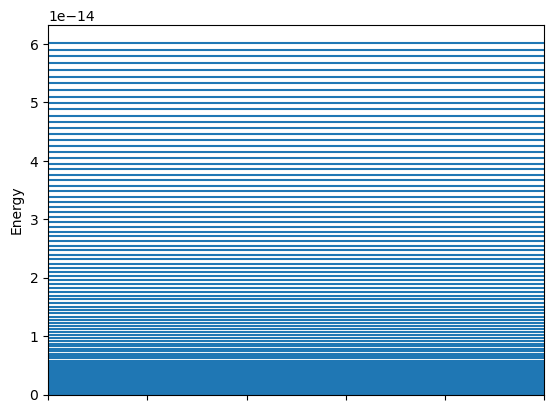

In [20]:
#plt.plot (n_integers, E_levels)

for i in range(points):
    plt.axhline(E_levels[i])
UpperLim= E_levels[points-1] +0.05*E_levels[points-1]
plt.ylim([0,UpperLim])
plt.tick_params(labelbottom=False)
plt.ylabel ("Energy")

## Comparing energy levels of two different systems

#### Define System 1

In [80]:
#Define System 1

m1 = 9.11e-31 #kg
a1 = 1e-9 #m
E_levels_1 = [None]*points

for i in range(points):
    n_integers[i]  = i +1
    E_levels_1[i] = (h**2)*(n_integers[i]**2) / (8*m*(a1**2))

#### Define System 2

In [51]:
#Define System 2

m2 = 9.11e-31
a2 = 2e-9 
E_levels_2 = [None]*points

for i in range(points):
    n_integers[i]  = i+1 
    E_levels_2[i] = (h**2)*(n_integers[i]**2) / (8*m*(a2**2))

In the above cells we have made two systems to compare that are the same except for their box length. You could also choose to change the mass (or both mass and length!). By defining the systems separately you can easily go back and tweak the parameters to see what changes it causes

#### Create Side by Side Plots

Below is some code to make two plots next to each other with a shared y-axis so it is easy to compare values

Text(0.5, 1.0, 'System 2,  Box Length 2e-09m')

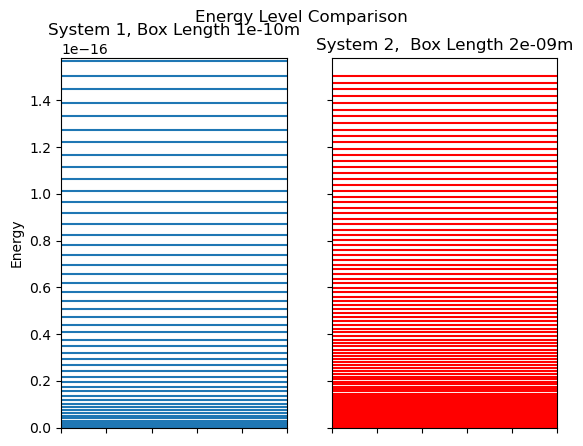

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
plt.ylim([0,1e-105])
ax1.set_ylabel ('Energy')
fig.suptitle('Energy Level Comparison')

for i in range(points):
    ax1.axhline(E_levels_1[i])

for i in range(points):
    ax2.axhline(E_levels_2[i], color='r')
    
UpperLim2= E_levels_2[points-1] +0.05*E_levels_2[points-1]
plt.ylim([0,UpperLim2])
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax1.set_title ('System 1, Box Length ' +str(a)+ 'm')
ax2.set_title ('System 2,  Box Length ' +str(a2)+ 'm')

#### Question 2: 
What happens to the energy level spacing as the box length is increased? Does what you see above match the correspondence principle?

#### Answer:

## Calculate change in energy and wavelength

### Single Calculation

In [53]:
start_n = 1
end_n = 2
deltaE = E_levels[end_n]-E_levels [start_n]
wavelength = h*c/deltaE
print (deltaE, 'J')
print (wavelength, 'm')
print (wavelength*10**9, 'nm')


3.012396805357339e-17 J
6.576736492604891e-09 m
6.576736492604891 nm


### Calculate Change in Energy from multiple start and end level

In [54]:
start_n_array = [1,2,3]
end_n_array = [1,2,3,4,5]
print ('n start', 'n final', '\t', 'energy')
for i in range(len(start_n_array)):
  for j in range(len(end_n_array)):
    end_n = end_n_array[j]
    start_n = start_n_array[i]
    if i != j and j>i:
      deltaE = E_levels[end_n]-E_levels [start_n]
      print (start_n_array[i], '\t', end_n_array[j], '\t',  deltaE)

n start n final 	 energy
1 	 2 	 3.012396805357339e-17
1 	 3 	 7.229752332857612e-17
1 	 4 	 1.2652066582500817e-16
1 	 5 	 1.9279339554286965e-16
2 	 3 	 4.2173555275002733e-17
2 	 4 	 9.63966977714348e-17
2 	 5 	 1.6266942748929628e-16
3 	 4 	 5.4223142496432066e-17
3 	 5 	 1.2049587221429355e-16


As we go to high n levels the correspondence principle tells us that the quantum model should start to match the classical model, ie the levels become continuous. Although this is not immeadiately visible based on the plots or number above, the difference in change in energy between levels divided by the actual energy gets smaller. Write some code to demonstrate this below.

In [83]:
#Code to show how delta E / En is vastly different at high n and low n

high_n = (E_levels[6]-E_levels[5]) / E_levels[6]
low_n = (E_levels[2]-E_levels[1]) / E_levels[2]
print (E_levels[9])
print ('n=1 to n=2 ---', low_n)
print ('n=98 to n=99 ---', high_n)

6.024921181348256e-18
n=1 to n=2 --- 0.5555555555555556
n=98 to n=99 --- 0.26530612244897955


#### Question 3
Comment on what you found doing this calculation

#### Answer 3

## Application Challenge (Question 4)

Last week you looked at conjugated dyes and determined the molecule length using the particle in the box model. Write some code below to show how a molecule of a certain length would absorb a photon in the UV-Vis region.
Work backwards from the wavelength you want your molecule to absorb at (anywhere is UV-Vis) to the length of box needed. Then propose a molecule that might fullfill this. 

It is ok to reference your work from last week, or (as always) reuse code that you wrote above.

In [ ]:
#Application Challenge Work

Application Challenge Explanation: 



# 2-D and 3-D Particle in a Box

Now we will work on a 3-D box. Follow the same pattern as before. 

In [86]:
#Define our box side lengths
b1 = a1#m 
b2 = b1 #m
b3 = b1 #m

#### Question 5
What does setting b2 and b3 equal to b1 do to our box?

#### Answer 5

#### Question 6
Why did we use b as the side lengths rather than 'a' that we had used earlier? Think of this question in terms of coding rather than chemistry.

#### Answer 6

## Calculate Energy of a Single Level

In [88]:
#Calculate for one energy level

nx= 2
ny = 5
nz = 2

En= ((h**2)/(8*m))*(((nx**2)/b1**2)+((ny**2)/b2**2)+((nz**2)/b3**2)) 

print ('The energy level at nx =', nx, 'ny =', ny, 'and nz=', nz, 'is', En)

The energy level at nx = 2 ny = 5 and nz= 2 is 1.9882239898449248e-18


## Calculate Energy of Multiple Levels (2-D Box)

Here we are going to return to a 2-D box. Why? Think about how we would need to generate values of n. For the 3-D box we need to vary and keep track of three variables. Although this is possible using 3-D array, the goal is to keep this accessible to those just learning coding and a 2-d box will show some of the points we would want to see in a 3-D box anyways 

In [98]:
points = 100 #number of energy levels we will calculate for both nx and ny

#Here we will use a matrix (2-D array), the index of the rows and columns will be our nx and ny values respectively.
#All indexes start at zero, even though our n values can't. We will just ignore these points. 
rows = points #Creates the number of rows which will be our nx values
cols = points #Creates the number of columns, our ny values
Energy2D = [[0 for _ in range(cols)] for _ in range(rows)] #Creates our matrix. The values in the matrix will be the energy

#Lets double check this is working. the matrix should be full of zeros right now
# When calling a matrix we label the row first and then the column

print ('Does our matrix contain zeros?', Energy2D[2][1])




Does our matrix contain zeros? 0


In [101]:
#Now lets fill the array

for i in range(points): #cycles through nx values
    for j in range (points): #Cycles through ny values
      Energy2D[i][j] = ((h**2)/(8*m))*(((i**2)/b1**2)+((j**2)/b2**2))
    
print (Energy2D[2][3], 'J')

7.832397535752732e-19 J


## Create Plots of Energy Levels

We now have nx and ny. Remember that it is not necessarily straightforward in what order the combos will give the lowest energy. There is also degeneracy. There are many tools in Python to analyze some of these aspects. However below we will start with making a simple heat map.

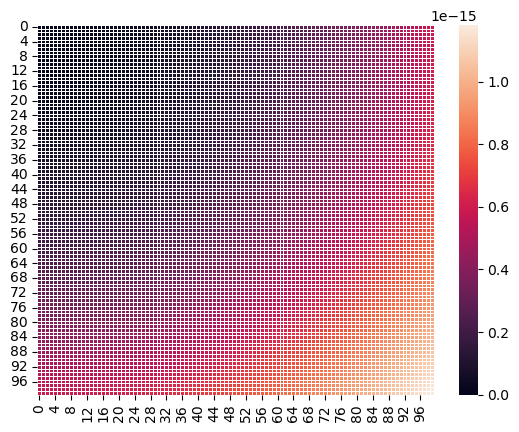

In [105]:
#This will create a heat map of the matrix
ax = sns.heatmap(Energy2D, linewidth=0.5)
plt.show()

#Add in axis labels??

#### Question 7
What information can you glean from this? What patterns do you see in the plot? What would be a more useful plot to view if you are thinking about doing spectroscopy?

#### Answer 7

## Calculate Energy Differences and Wavelength

Create some code below to calculate the difference in energy between 2 energy levels. Then convert that difference to a wavelength in nanometers. 

In [107]:
#Code to calcualte energy difference between two levels in a 2-D box


#print the energy

In [108]:
#Code to convert value above to wavelength in nm

#print the wavelength

## Wrap Up Questions

#### Question 8
What chemistry concepts did you learn or solidify today?

Answer:

#### Question 9
What coding concepts did you learn or solidify today?

Answer:

#### Question 10
Why or why not was using Python to calculate your data useful?

Answer:

#### Question 11
For Dr. Vollbrecht's reference, if you had to work on this outside of lab, how much additional time did you spend on it?

Answer: